# Comparação de Resultados

## Objetivo

Comparar o desempenho dos modelos de regressão treinados de forma global (Etapa 3) com os modelos treinados individualmente por cluster (Etapa 4).

A hipótese central do projeto é que segmentar os clientes em grupos homogêneos antes de aplicar a regressão melhora a capacidade preditiva dos modelos.

Esta etapa responde à pergunta: **a clusterização realmente ajudou?**

As métricas utilizadas para comparação são:

- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- R²

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## Carregamento dos Dados

Nesta etapa carregamos os resultados gerados pelas etapas anteriores:

- `resultados_global.csv` — métricas dos três modelos treinados no dataset completo (Etapa 3)
- `resultados_clusters.csv` — métricas dos três modelos treinados por cluster (Etapa 4)

In [2]:
resultados_global   = pd.read_csv('../data/resultados_global.csv')
resultados_clusters = pd.read_csv('../data/resultados_clusters.csv')

print('=== Resultados Globais (Etapa 3) ===')
print(resultados_global.to_string(index=False))

print('\n=== Resultados por Cluster (Etapa 4) ===')
print(resultados_clusters.to_string(index=False))

=== Resultados Globais (Etapa 3) ===
                 Modelo         MAE          MSE        RMSE       R²
          KNN Regressor 3514.202219 3.061814e+07 5533.366286 0.802780
       Regressão Linear 4181.194474 3.359692e+07 5796.284659 0.783593
Decision Tree Regressor 3074.866286 4.015399e+07 6336.717525 0.741357

=== Resultados por Cluster (Etapa 4) ===
 Cluster                  Modelo         MAE          MSE        RMSE       R²
       0        Regressão Linear 4278.497154 3.676486e+07 6063.403202 0.637279
       0           KNN Regressor 3540.223287 3.161444e+07 5622.672289 0.688093
       0 Decision Tree Regressor 4277.416821 6.506309e+07 8066.169483 0.358089
       1        Regressão Linear 4070.041396 4.122772e+07 6420.881746 0.758114
       1           KNN Regressor 3464.887759 3.108699e+07 5575.571111 0.817611
       1 Decision Tree Regressor 3104.992557 4.234218e+07 6507.087239 0.751576
       2        Regressão Linear 3286.583315 2.106133e+07 4589.262825 0.861228
       2 

## Tabela Comparativa Completa

Para facilitar a comparação, unimos os resultados globais e por cluster em uma única tabela.

O modelo global é listado como referência (baseline) ao lado dos resultados segmentados, permitindo identificar em quais clusters a abordagem por segmentação superou — ou ficou abaixo — do modelo treinado sem clusterização.

In [3]:
# Prepara resultados globais no mesmo formato dos resultados por cluster
global_fmt = resultados_global.copy()
global_fmt.insert(0, 'Cluster', 'Global')

# Prepara resultados por cluster com rótulo legível
clusters_fmt = resultados_clusters.copy()
clusters_fmt['Cluster'] = 'Cluster ' + clusters_fmt['Cluster'].astype(str)

# Junta em uma única tabela e ordena
comparacao = pd.concat([global_fmt, clusters_fmt], ignore_index=True)
comparacao = comparacao.sort_values(['Cluster', 'R²'], ascending=[True, False]).reset_index(drop=True)

# Formata para exibição
comp_fmt = comparacao.copy()
comp_fmt['MAE']  = comp_fmt['MAE'].map('${:,.2f}'.format)
comp_fmt['MSE']  = comp_fmt['MSE'].map('{:,.0f}'.format)
comp_fmt['RMSE'] = comp_fmt['RMSE'].map('${:,.2f}'.format)
comp_fmt['R²']   = comp_fmt['R²'].map('{:.4f}'.format)

display(comp_fmt)

,Cluster,Modelo,MAE,MSE,RMSE,R²
0,Cluster 0,KNN Regressor,"$3,540.22","31,614,444","$5,622.67",0.6881
1,Cluster 0,Regressão Linear,"$4,278.50","36,764,858","$6,063.40",0.6373
2,Cluster 0,Decision Tree Regressor,"$4,277.42","65,063,090","$8,066.17",0.3581
3,Cluster 1,KNN Regressor,"$3,464.89","31,086,993","$5,575.57",0.8176
4,Cluster 1,Regressão Linear,"$4,070.04","41,227,722","$6,420.88",0.7581
5,Cluster 1,Decision Tree Regressor,"$3,104.99","42,342,184","$6,507.09",0.7516
6,Cluster 2,KNN Regressor,"$2,627.72","11,174,565","$3,342.84",0.9264
7,Cluster 2,Regressão Linear,"$3,286.58","21,061,333","$4,589.26",0.8612
8,Cluster 2,Decision Tree Regressor,"$3,080.99","36,259,246","$6,021.57",0.7611
9,Global,KNN Regressor,"$3,514.20","30,618,142","$5,533.37",0.8028


### Interpretação

A tabela reúne todas as 12 combinações possíveis (4 contextos × 3 modelos). Os resultados devem ser lidos comparando sempre cada linha com o seu equivalente global — ou seja, o KNN do Cluster 2 deve ser comparado com o KNN Global, e não com a Regressão Linear do Cluster 0.

## Comparativo do Modelo Escolhido — KNN Global vs. KNN por Cluster

O KNN Regressor foi o modelo com melhor desempenho tanto no cenário global quanto nos três clusters individualmente. Por isso, ele é o modelo escolhido para a predição final (Etapa 6).

O gráfico abaixo compara diretamente o KNN treinado com todos os dados (baseline) contra os KNNs especializados por cluster, nas duas métricas principais: R² e MAE.

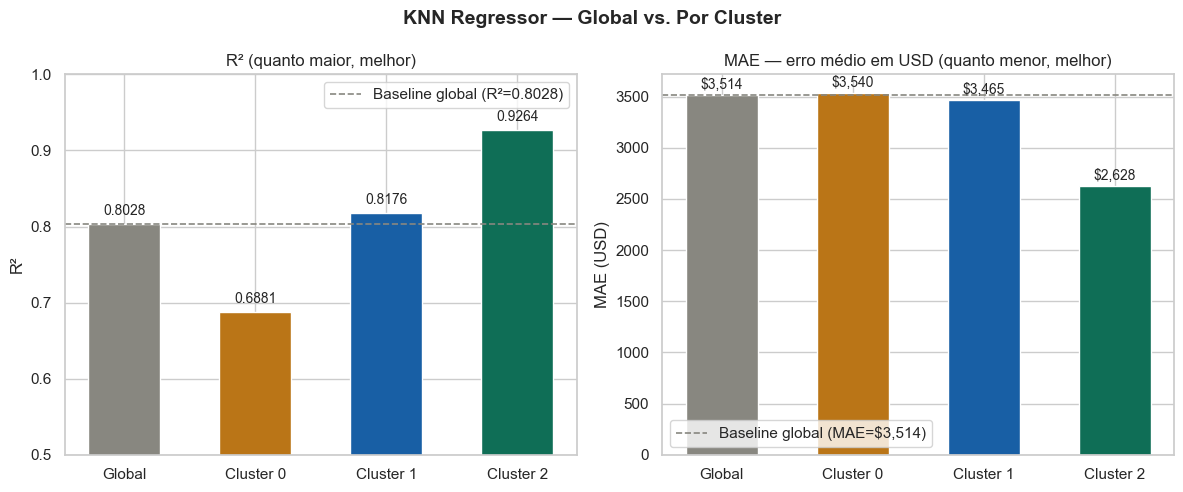

Gráfico salvo: data/comparativo_knn_global_vs_cluster.png


In [4]:
# Extrai KNN global
knn_global   = resultados_global[resultados_global['Modelo'] == 'KNN Regressor'].iloc[0]

# Extrai KNN por cluster (na ordem 0, 1, 2)
knn_clusters = (
    resultados_clusters[resultados_clusters['Modelo'] == 'KNN Regressor']
    .sort_values('Cluster')
    .reset_index(drop=True)
)

labels   = ['Global', 'Cluster 0', 'Cluster 1', 'Cluster 2']
r2_vals  = [knn_global['R²']]  + knn_clusters['R²'].tolist()
mae_vals = [knn_global['MAE']] + knn_clusters['MAE'].tolist()
cores    = ['#888780', '#BA7517', '#185FA5', '#0F6E56']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('KNN Regressor — Global vs. Por Cluster', fontsize=14, fontweight='bold')

# --- R² ---
bars = axes[0].bar(labels, r2_vals, color=cores, edgecolor='white', width=0.55)
axes[0].axhline(y=knn_global['R²'], color='#888780', linestyle='--',
                linewidth=1.2, label=f'Baseline global (R²={knn_global["R²"]:.4f})')
axes[0].set_title('R² (quanto maior, melhor)')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.5, 1.0)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)
axes[0].legend()

# --- MAE ---
bars2 = axes[1].bar(labels, mae_vals, color=cores, edgecolor='white', width=0.55)
axes[1].axhline(y=knn_global['MAE'], color='#888780', linestyle='--',
                linewidth=1.2, label=f'Baseline global (MAE=${knn_global["MAE"]:,.0f})')
axes[1].set_title('MAE — erro médio em USD (quanto menor, melhor)')
axes[1].set_ylabel('MAE (USD)')
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/comparativo_knn_global_vs_cluster.png', bbox_inches='tight')
plt.show()
print('Gráfico salvo: data/comparativo_knn_global_vs_cluster.png')

### Interpretação

A linha tracejada representa o desempenho do modelo global — tudo acima dela indica melhora com a segmentação, tudo abaixo indica piora.

- **Cluster 2** apresentou o maior ganho: R² subiu de 0,8028 para 0,9264, e o MAE caiu de $3.514 para $2.628, uma redução de aproximadamente 25% no erro médio.
- **Cluster 1** apresentou melhora moderada: R² de 0,8028 para 0,8176, com MAE ligeiramente menor.
- **Cluster 0** ficou abaixo do baseline: R² de 0,8028 caiu para 0,6881. A segmentação não beneficiou este grupo.

## Comparativo de Todos os Modelos por Cluster

Além do modelo escolhido, é importante visualizar como os três algoritmos se comportaram em cada contexto.

O gráfico abaixo agrupa os resultados por modelo, mostrando o R² e o MAE de cada algoritmo nos três clusters e no cenário global.

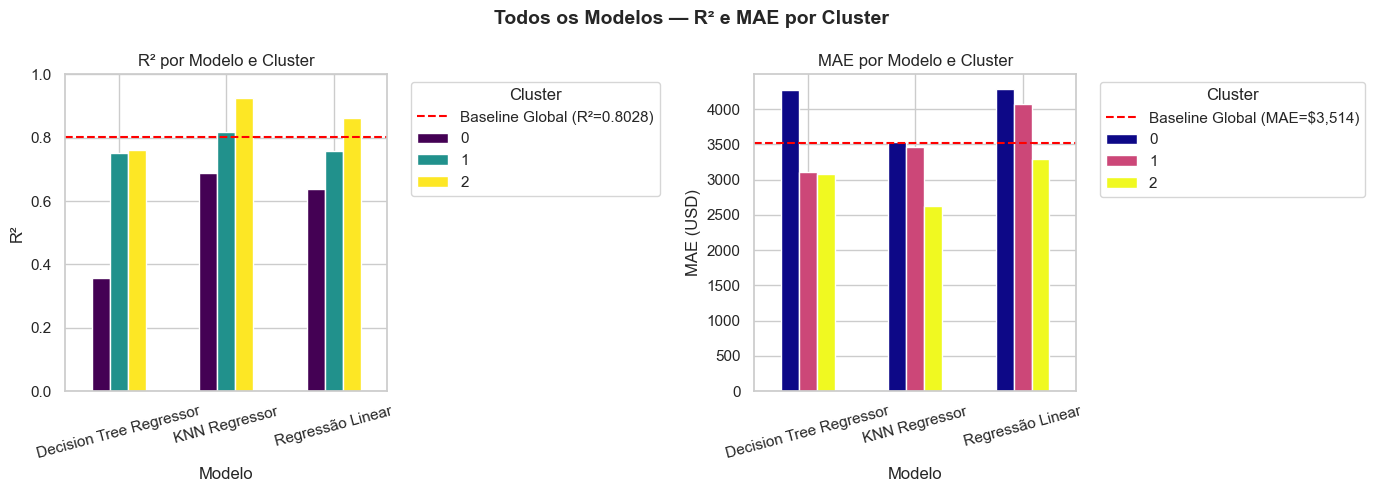

Gráfico salvo: data/comparacao_todos_modelos.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Todos os Modelos — R² e MAE por Cluster', fontsize=14, fontweight='bold')

r2_pivot  = resultados_clusters.pivot(index='Modelo', columns='Cluster', values='R²')
mae_pivot = resultados_clusters.pivot(index='Modelo', columns='Cluster', values='MAE')

global_best_r2  = resultados_global['R²'].max()
global_best_mae = resultados_global.loc[resultados_global['R²'].idxmax(), 'MAE']

# --- R² ---
r2_pivot.plot(kind='bar', ax=axes[0], colormap='viridis', edgecolor='white')
axes[0].axhline(y=global_best_r2, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline Global (R²={global_best_r2:.4f})')
axes[0].set_title('R² por Modelo e Cluster')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Cluster', bbox_to_anchor=(1.05, 1))

# --- MAE ---
mae_pivot.plot(kind='bar', ax=axes[1], colormap='plasma', edgecolor='white')
axes[1].axhline(y=global_best_mae, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline Global (MAE=${global_best_mae:,.0f})')
axes[1].set_title('MAE por Modelo e Cluster')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('MAE (USD)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Cluster', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('../data/comparacao_todos_modelos.png', bbox_inches='tight')
plt.show()
print('Gráfico salvo: data/comparacao_todos_modelos.png')

### Interpretação

O KNN Regressor foi o algoritmo de melhor desempenho nos três clusters, confirmando a escolha feita na Etapa 4.

A Decision Tree apresentou o pior resultado geral, especialmente no Cluster 0 (R²=0,3581), indicando que o algoritmo sofreu com overfitting no conjunto de treino e não generalizou bem para o teste nesse grupo.

A Regressão Linear manteve desempenho estável, sendo competitiva no Cluster 2 (R²=0,8612), mas consistentemente superada pelo KNN.

## Análise Crítica

A segmentação por clusters trouxe benefícios reais para dois dos três grupos identificados, mas não para todos. A análise abaixo detalha o comportamento de cada cluster e as razões prováveis para os resultados obtidos.

In [6]:
# Resumo do melhor modelo por cluster vs baseline
melhor_por_cluster = (
    resultados_clusters
    .loc[resultados_clusters.groupby('Cluster')['R²'].idxmax()]
    .sort_values('Cluster')
    .reset_index(drop=True)
)

global_best = resultados_global.loc[resultados_global['R²'].idxmax()]

print('Melhor modelo por cluster vs. baseline global:')
print('=' * 65)
print(f"  {'Global':<12} {global_best['Modelo']:<25} R²={global_best['R²']:.4f}  MAE=${global_best['MAE']:,.2f}  [BASELINE]")
for _, row in melhor_por_cluster.iterrows():
    delta_r2  = row['R²']  - global_best['R²']
    delta_mae = row['MAE'] - global_best['MAE']
    sinal_r2  = '+' if delta_r2  >= 0 else ''
    sinal_mae = '+' if delta_mae >= 0 else ''
    print(f"  {'Cluster '+str(int(row['Cluster'])):<12} {row['Modelo']:<25} "
          f"R²={row['R²']:.4f} ({sinal_r2}{delta_r2:.4f})  "
          f"MAE=${row['MAE']:,.2f} ({sinal_mae}${delta_mae:,.2f})")

Melhor modelo por cluster vs. baseline global:
  Global       KNN Regressor             R²=0.8028  MAE=$3,514.20  [BASELINE]
  Cluster 0    KNN Regressor             R²=0.6881 (-0.1147)  MAE=$3,540.22 (+$26.02)
  Cluster 1    KNN Regressor             R²=0.8176 (+0.0148)  MAE=$3,464.89 ($-49.31)
  Cluster 2    KNN Regressor             R²=0.9264 (+0.1236)  MAE=$2,627.72 ($-886.48)


### Cluster 0 — Não-fumantes, custo baixo/médio (n=649)

O Cluster 0 é o maior grupo do dataset, com 649 registros. Apesar de reunir apenas não-fumantes, o grupo apresenta alta variação interna de idade, IMC e número de filhos — fatores que afetam o custo de formas bastante diferentes entre si.

O R² do KNN caiu de **0,8028 (global) para 0,6881**, uma piora de 11,5 pontos percentuais. Isso indica que a segmentação **não beneficiou** este grupo. O subconjunto de teste (~130 registros) pode não ter sido suficiente para o KNN encontrar vizinhos representativos, e o valor fixo de `k=5` pode não ser o ideal para a heterogeneidade interna deste cluster.

### Cluster 1 — Fumantes, custo alto (n=325)

O Cluster 1 reúne os fumantes, que apresentam custos sistematicamente mais altos. Por ser o grupo definido principalmente por uma variável binária de alto impacto (`smoker`), o modelo especializado encontra padrões mais claros dentro do grupo.

O R² subiu de **0,8028 para 0,8176**, com MAE reduzido de $3.514 para $3.465. A melhora é **modesta mas consistente**, e o modelo por cluster é superior ao global neste segmento.

### Cluster 2 — Não-fumantes, mais velhos e/ou com mais filhos (n=364)

O Cluster 2 foi o que mais se beneficiou da segmentação. Este grupo apresenta o perfil mais homogêneo do dataset — não-fumantes com idades e estruturas familiares semelhantes —, o que torna o comportamento dos custos muito mais regular e previsível.

O R² subiu de **0,8028 para 0,9264**, e o RMSE caiu de $5.533 para $3.343 — uma redução de aproximadamente **40% no erro quadrático médio**. Este é o maior ganho do projeto e demonstra com clareza o potencial da abordagem de segmentação + regressão especializada.

### Observação sobre a variável `smoker`

A análise dos clusters revela que o algoritmo K-Means separou espontaneamente fumantes de não-fumantes como principal critério de agrupamento — sem que essa variável fosse explicitamente sinalizada como mais importante. Isso confirma que o tabagismo é o fator de maior peso na variação dos custos de seguro médico neste dataset.

## Conclusão

A abordagem de segmentação por clusters seguida de regressão especializada demonstrou ser **superior ao modelo global em dois dos três clusters** identificados pelo K-Means.

O resultado mais expressivo foi o Cluster 2 (não-fumantes mais velhos/com filhos), onde o KNN especializado atingiu R²=0,9264 — ante 0,8028 do baseline global —, com redução de 40% no RMSE. Isso indica que, para grupos internamente homogêneos, a segmentação prévia aumenta significativamente a precisão das previsões.

Por outro lado, o Cluster 0 (não-fumantes de custo baixo/médio) apresentou desempenho inferior ao baseline, reforçando que a segmentação só traz ganhos quando os grupos formados são suficientemente coesos. Grupos heterogêneos podem não ter amostra de teste grande o suficiente para algoritmos baseados em similaridade como o KNN.

**Recomendação para uso em produção:** o sistema de predição deve primeiro classificar o novo paciente no cluster correspondente — utilizando o modelo K-Means treinado na Etapa 2 — e em seguida aplicar o modelo de regressão especializado daquele cluster. Essa é a estratégia implementada na Etapa 6 (`predict.py`).